In [1]:
import os
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
sys.path.append(os.path.abspath('..'))

from src.optimization.microgrid import Microgrid

plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16
})

In [2]:
#Creates a microgrid object with specified components that holds data and parameters
microgrid = Microgrid(
    loads=['StudentServices'], 
    pv_generators=['BioEngineeringPV'], 
    batteries=['BatteryStorage'] 
)

In [3]:

print("Loads:", microgrid.loads[0].name)
print("PV Generators:", microgrid.pv_generators[0].name)
print("Batteries:", microgrid.batteries[0].name)
# load data for the components
print("total load:", microgrid.get_total_load())
print("total PV generation:", microgrid.get_total_pv_generation())
print("total battery capacity:", microgrid.get_total_battery_storage())
print("number of time steps:", microgrid.get_total_pv_generation().shape[0])


Loads: StudentServices
PV Generators: BioEngineeringPV
Batteries: BatteryStorage
total load: [95.5515  94.317   95.8335  ... 86.87075 85.92175 81.11675]
total PV generation: [ 5.273    8.9065  17.85175 ...  0.07025  0.0705   0.067  ]
total battery capacity: (2500, 5000)
number of time steps: 44776


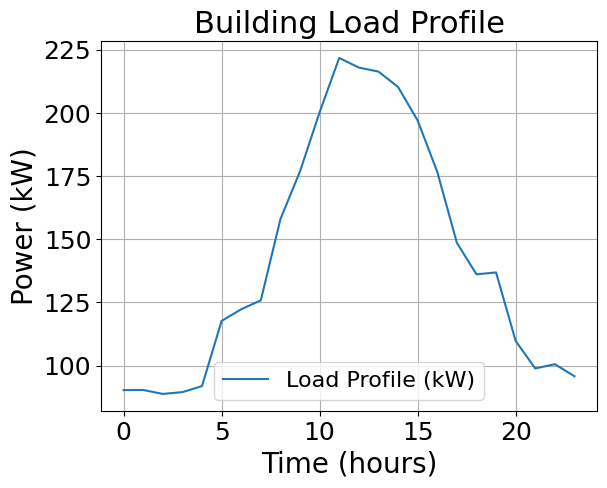

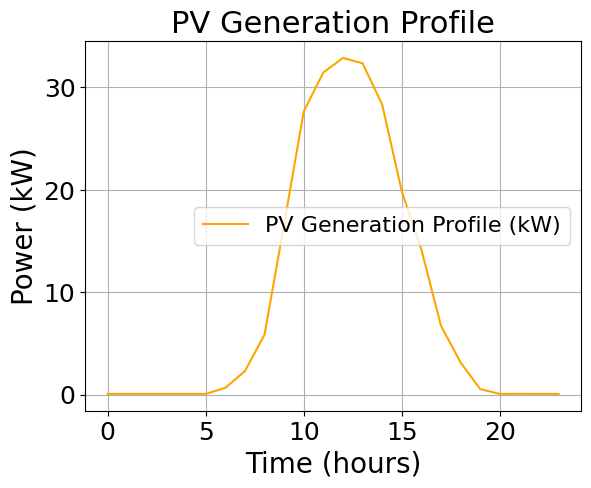

In [4]:

load_profile = microgrid.loads[0].get_load_profile('2018-07-16', '2018-07-17')  # kW
T = len(load_profile)

plt.figure()
plt.plot(range(T), load_profile, label='Load Profile (kW)')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('Building Load Profile')
plt.legend()
plt.grid()
plt.show()

pv_profile = microgrid.pv_generators[0].get_generation_profile('2018-07-16', '2018-07-17')  # kW

plt.figure()
plt.plot(range(T), pv_profile, label='PV Generation Profile (kW)', color='orange')
plt.xlabel('Time (hours)')
plt.ylabel('Power (kW)')
plt.title('PV Generation Profile')
plt.legend()
plt.grid()
plt.show()




In [5]:
results_dict = microgrid.optimize(start_date='2018-07-16', end_date='2018-07-17')
print("Timestamps:", pd.to_datetime(results_dict['timestamps'], unit='s'))


Debug: Load shape: (24,), PV shape: (24,), Timestamps shape: (24,)
Timestamps: DatetimeIndex(['2018-07-16 00:00:00', '2018-07-16 01:00:00',
               '2018-07-16 02:00:00', '2018-07-16 03:00:00',
               '2018-07-16 04:00:00', '2018-07-16 05:00:00',
               '2018-07-16 06:00:00', '2018-07-16 07:00:00',
               '2018-07-16 08:00:00', '2018-07-16 09:00:00',
               '2018-07-16 10:00:00', '2018-07-16 11:00:00',
               '2018-07-16 12:00:00', '2018-07-16 13:00:00',
               '2018-07-16 14:00:00', '2018-07-16 15:00:00',
               '2018-07-16 16:00:00', '2018-07-16 17:00:00',
               '2018-07-16 18:00:00', '2018-07-16 19:00:00',
               '2018-07-16 20:00:00', '2018-07-16 21:00:00',
               '2018-07-16 22:00:00', '2018-07-16 23:00:00'],
              dtype='datetime64[ns]', freq=None)


In [6]:
print("Grid Import (kW):", results_dict['grid_import'])

Grid Import (kW): [1.68122289e+02 1.68122289e+02 1.68122289e+02 1.68122289e+02
 1.68122289e+02 1.68122289e+02 1.68122289e+02 1.68122289e+02
 1.68122289e+02 1.68122289e+02 1.68122289e+02 1.68122289e+02
 1.68122289e+02 1.68122289e+02 1.68122289e+02 1.68122289e+02
 1.67193390e-08 1.81653986e-08 1.87396187e-08 1.85180572e-08
 1.97950881e-08 1.68122289e+02 1.68122289e+02 1.68122289e+02]


In [7]:
print("SOC", results_dict['soc'])

SOC [2500.         2425.9659875  2351.98802501 2276.52735001 2201.73143752
 2129.20151252 2081.18657503 2036.99515003 1994.59732504 1979.34005004
 1971.79440005 1976.02756255 1997.07643756 2013.14470006 2028.20548756
 2041.31592507 2049.88512507 2204.26297506 2339.04090004 2465.35242502
 2594.8367125  2698.99874999 2633.10433749 2568.82065    2500.        ]


In [8]:
print("cost breakdown:", results_dict['cost_breakdown'])

cost breakdown: {'total_cost': np.float64(589.7729915053735), 'energy_charges': np.float64(589.7729915053735), 'demand_charges': 0.0, 'max_demand': 0.0, 'on_peak_demand': 0.0, 'demand_charges_applied': False}


In [9]:
print("total emissions (kg CO2):", results_dict['total_emissions_gco2'])

total emissions (kg CO2): 733436.1778050238



Running objective: cost ...
Debug: Load shape: (24,), PV shape: (24,), Timestamps shape: (24,)
  Status       : optimal
  Total Cost   : $589.77
  Total Emissions: 733436.2 gCO2e

Running objective: emissions ...
Debug: Load shape: (24,), PV shape: (24,), Timestamps shape: (24,)
  Status       : optimal
  Total Cost   : $683.59
  Total Emissions: 96839.5 gCO2e

Running objective: weighted ...
Debug: Load shape: (24,), PV shape: (24,), Timestamps shape: (24,)
  Status       : optimal
  Total Cost   : $683.59
  Total Emissions: 83843.0 gCO2e


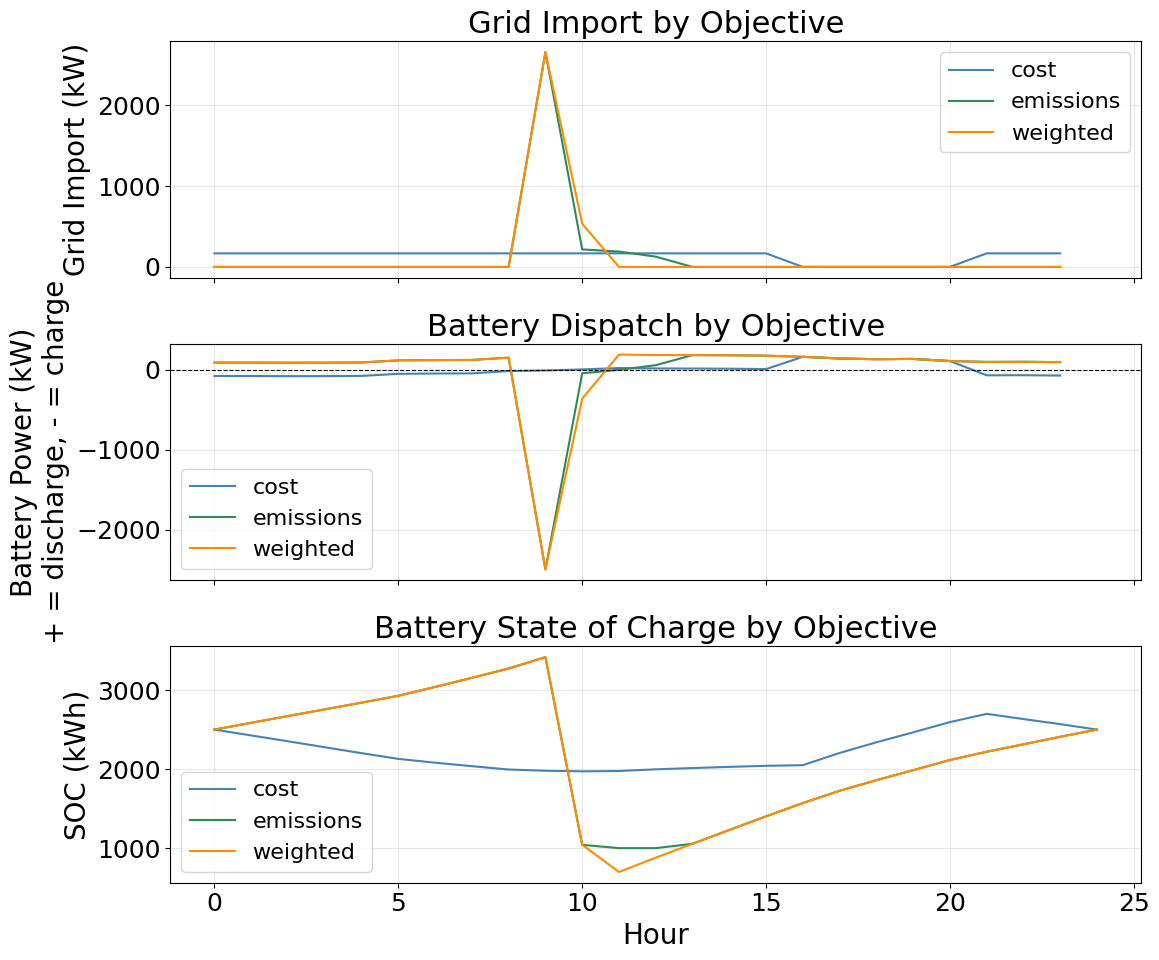


── Summary ─────────────────────────────────────────────────────
Objective      Total Cost ($)  Emissions (gCO2e)
------------------------------------------------
cost                   589.77           733436.2
emissions              683.59            96839.5
weighted               683.59            83843.0


In [11]:
START = '2018-07-16'
END   = '2018-07-17'

LOADS       = ['StudentServices']               # adjust to your asset names in DATASETS
PV          = ['BioEngineeringPV']              # set to None if no PV
BATTERIES   = ['BatteryStorage']                # set to None if no battery

mg = Microgrid(loads=LOADS, pv_generators=PV, batteries=BATTERIES)

results = {}

for objective in ['cost', 'emissions', 'weighted']:
    print(f"\nRunning objective: {objective} ...")
    results[objective] = mg.optimize(
        start_date=START,
        end_date=END,
        objective_type=objective,
        round_trip_efficiency=0.95,
        include_soc_penalty=True,
        soc_min=0.20,
        soc_max=0.80,
    )
    r = results[objective]
    print(f"  Status       : {r['status']}")
    print(f"  Total Cost   : ${r['cost_breakdown']['total_cost']:.2f}")
    print(f"  Total Emissions: {r['total_emissions_gco2']:.1f} gCO2e")

#Plot comparison 
hours = np.arange(24)
timestamps_hr = pd.to_datetime(results['cost']['timestamps'], unit='s').hour

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
colors = {'cost': 'steelblue', 'emissions': 'seagreen', 'weighted': 'darkorange'}
ax = axes[0]
for obj, r in results.items():
    ax.plot(hours, r['grid_import'], label=obj, color=colors[obj])
ax.set_ylabel('Grid Import (kW)')
ax.set_title('Grid Import by Objective')
ax.legend()
ax.grid(True, alpha=0.3)

#Battery power per objective
ax = axes[1]
for obj, r in results.items():
    ax.plot(hours, r['battery_power'], label=obj, color=colors[obj])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Battery Power (kW)\n+ = discharge, - = charge')
ax.set_title('Battery Dispatch by Objective')
ax.legend()
ax.grid(True, alpha=0.3)

#SOC per objective
ax = axes[2]
for obj, r in results.items():
    ax.plot(r['soc'], label=obj, color=colors[obj])
ax.set_ylabel('SOC (kWh)')
ax.set_xlabel('Hour')
ax.set_title('Battery State of Charge by Objective')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n── Summary ─────────────────────────────────────────────────────")
print(f"{'Objective':<12} {'Total Cost ($)':>16} {'Emissions (gCO2e)':>18}")
print("-" * 48)
for obj, r in results.items():
    cost = r['cost_breakdown']['total_cost']
    emissions = r['total_emissions_gco2']
    print(f"{obj:<12} {cost:>16.2f} {emissions:>18.1f}")